In [526]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import cufflinks as cf


# Get Data

In [529]:
data = pd.read_csv("prices.csv",index_col ="Date", parse_dates = ["Date"]
                  )


In [531]:
data

,ADANIENT.NS,ADANIPORTS.NS,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,MARUTI.NS,NTPC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TITAN.NS
Date,,,,,,,,,,,,,,,,,,,,
2020-01-01,205.886520,362.584290,745.586853,413.532196,433.316467,605.529358,1749.931396,519.137939,633.151123,168.796616,333.417084,1180.674683,509.727966,6945.334961,94.731247,672.216187,303.138489,406.074005,1841.149536,1132.704834
2020-01-02,209.204865,367.864838,753.802612,414.973724,435.132690,609.389160,1751.286865,522.861633,631.303711,170.037216,332.919159,1212.536011,512.815125,6962.575684,94.614365,683.660217,307.534393,406.681763,1832.697754,1133.538574
2020-01-03,206.332260,367.240784,739.860901,409.833008,435.037109,600.698792,1741.708496,521.169006,641.013428,169.080215,330.041168,1203.297363,506.070770,6890.763184,93.016670,684.484009,302.458710,415.704620,1869.222046,1117.942017
2020-01-06,197.664932,365.032532,720.242737,390.604309,429.827362,587.698792,1730.864624,508.450500,634.869568,166.669830,329.134979,1186.803711,498.233917,6689.528809,92.665939,668.609314,289.134918,411.356781,1869.052246,1136.481201
2020-01-07,202.122406,369.449036,722.732300,391.674469,425.477966,597.004822,1735.608887,505.742401,625.460754,166.847046,332.779755,1190.183350,500.276245,6719.165527,93.951897,678.895691,288.591064,417.387543,1873.639038,1137.805298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,2248.800049,1493.599976,1225.000000,1011.400024,2122.899902,996.599976,2302.600098,1363.000000,1668.300049,388.406677,432.540009,4019.539795,3625.100098,16585.000000,320.827820,1563.471069,954.691650,1744.567627,3207.412598,3925.800049
2025-12-24,2222.699951,1494.300049,1226.300049,1011.700012,2123.699951,997.200012,2282.199951,1359.800049,1663.400024,387.691559,432.739990,4014.390137,3636.699951,16703.000000,320.133057,1551.028687,951.793884,1725.789673,3216.133789,3909.300049
2025-12-26,2229.899902,1487.099976,1228.199951,1000.000000,2105.399902,992.099976,2285.399902,1350.400024,1656.099976,385.355469,432.839996,4008.150879,3623.100098,16596.000000,321.671448,1552.024048,949.190735,1708.402588,3178.342529,3992.000000


# Calcuating number shares purchased 

In [534]:
shares_list  = []
for i in range(20):
    shares_list.append(500000/ data.iloc[0,i])

In [536]:
shares_list


[2428.522270730578,
 1378.9896981456861,
 670.6126831097207,
 1209.0956998803672,
 1153.8910651899153,
 825.7237959950178,
 285.7254867273675,
 963.1351554207627,
 789.7008815113209,
 2962.144698345862,
 1499.623217835924,
 423.48667872817936,
 980.9153765310488,
 71.99076830882015,
 5278.089501695067,
 743.8083313433676,
 1649.4111388809413,
 1231.302653425654,
 271.56946798042816,
 441.4212643917234]

# Portfolio daily movement 

In [539]:
portfolio_daily = (data * shares_list).sum(1).to_frame()

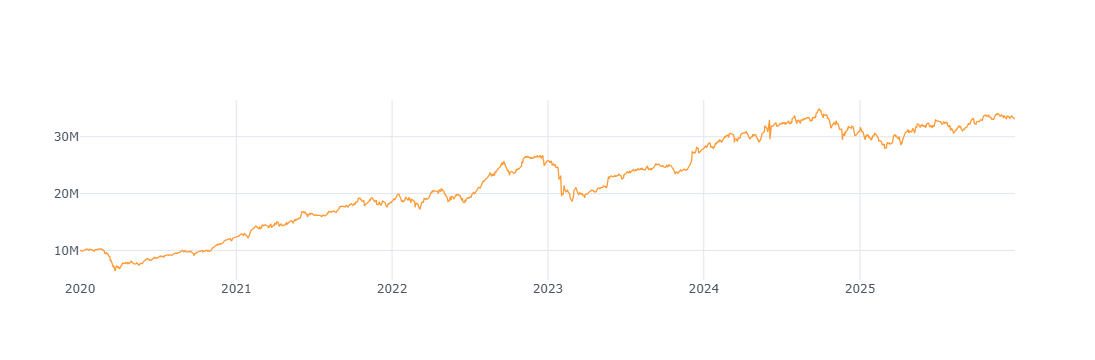

In [541]:
portfolio_daily.iplot()

In [543]:
portfolio_daily.columns = ["Portfolio daily move"]

In [545]:
portfolio_daily

,Portfolio daily move
Date,
2020-01-01,1.000000e+07
2020-01-02,1.006505e+07
2020-01-03,1.001276e+07
2020-01-06,9.844810e+06
2020-01-07,9.893028e+06
...,...
2025-12-23,3.356022e+07
2025-12-24,3.345781e+07
2025-12-26,3.339221e+07


In [547]:
portfolio_daily_ret = portfolio_daily.pct_change().dropna()

In [549]:
summery_stats = portfolio_daily_ret.agg(["mean","std"]).T
summery_stats.columns = ["Return","Risk"]
summery_stats["Return"] = summery_stats["Return"]*252
summery_stats["Risk"] = summery_stats["Risk"]*np.sqrt(252)



In [551]:
summery_stats

,Return,Risk
Portfolio daily move,0.229087,0.221663


In [553]:
def ann_risk_return(returns_df):
    summary = returns_df.agg(["mean", "std"]).T
    summary.columns = ["Return", "Risk"]
    summary.Return = summary.Return*252
    summary.Risk = summary.Risk * np.sqrt(252)
    return summary

In [555]:
summery_stats["sharpe"] = (summery_stats["Return"] -0.07).div(summery_stats["Risk"])

In [557]:
summery_stats

,Return,Risk,sharpe
Portfolio daily move,0.229087,0.221663,0.717699


# Index Data

In [560]:
index_data = pd.read_csv("new_Index_data.csv",index_col ="Date", parse_dates = ["Date"]
                  )

In [562]:
index_data.dropna(inplace =True)

In [564]:
nor_data = index_data.div(index_data.iloc[0],axis = 1).mul(100)

In [566]:
nor_data

,Nifty50,NiftyNext50,Sensex
Date,,,
2020-01-02,100.000000,100.000000,100.000000
2020-01-03,99.610751,99.547721,99.802175
2020-01-06,97.717780,97.645777,97.755418
2020-01-07,98.181040,98.133478,98.478376
2020-01-08,98.056768,97.908758,98.521662
...,...,...,...
2026-06-02,179.331896,191.199870,245.719791
2026-06-03,178.602382,190.565202,244.810733
2026-06-04,178.635621,190.654365,245.352368


In [568]:
nor_data ["Portfolio"] = portfolio_daily.div(portfolio_daily.iloc[0],axis = 1).mul(100)

In [570]:
nor_data.dropna(inplace =True)
nor_data

,Nifty50,NiftyNext50,Sensex,Portfolio
Date,,,,
2020-01-02,100.000000,100.000000,100.000000,100.650481
2020-01-03,99.610751,99.547721,99.802175,100.127645
2020-01-06,97.717780,97.645777,97.755418,98.448099
2020-01-07,98.181040,98.133478,98.478376,98.930275
2020-01-08,98.056768,97.908758,98.521662,98.745830
...,...,...,...,...
2025-12-23,205.456992,213.130791,242.146968,335.602204
2025-12-24,205.177987,212.845412,241.659681,334.578104
2025-12-26,204.295739,212.032864,241.672987,333.922078


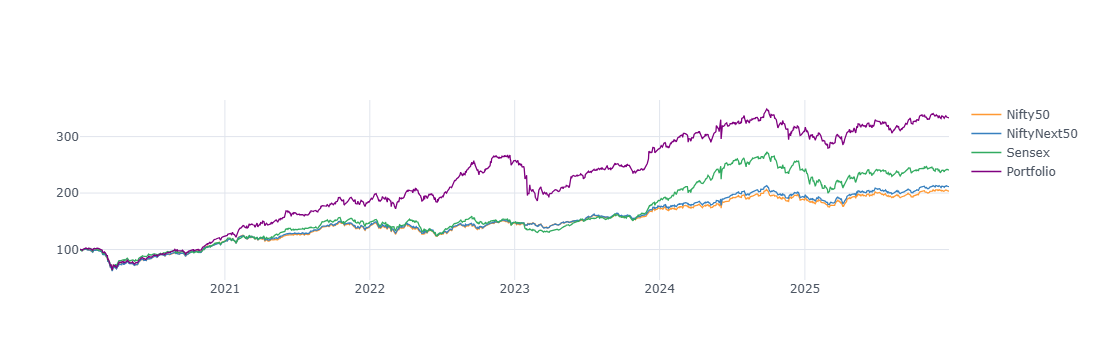

In [572]:
nor_data.iplot()

In [574]:
index_ret = index_data.loc["2020-01-01":"2025-12-30",:].pct_change().dropna()

In [576]:
index_ret

,Nifty50,NiftyNext50,Sensex
Date,,,
2020-01-03,-0.003892,-0.004523,-0.001978
2020-01-06,-0.019004,-0.019106,-0.020508
2020-01-07,0.004741,0.004995,0.007396
2020-01-08,-0.001266,-0.002290,0.000440
2020-01-09,0.015547,0.015846,0.013188
...,...,...,...
2025-12-23,-0.000498,0.000181,0.003683
2025-12-24,-0.001358,-0.001339,-0.002012
2025-12-26,-0.004300,-0.003818,0.000055


In [578]:
Main_stats =ann_risk_return(index_ret)

In [580]:
Main_stats

,Return,Risk
Nifty50,0.138355,0.183967
NiftyNext50,0.144346,0.181679
Sensex,0.169158,0.194745


In [582]:
Main_stats["sharpe"] = (Main_stats["Return"] -0.07).div(Main_stats["Risk"])
Main_stats

,Return,Risk,sharpe
Nifty50,0.138355,0.183967,0.371562
NiftyNext50,0.144346,0.181679,0.409213
Sensex,0.169158,0.194745,0.509168


In [584]:
data_ret = data.pct_change().dropna()

In [586]:
data_ret

,ADANIENT.NS,ADANIPORTS.NS,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,MARUTI.NS,NTPC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TITAN.NS
Date,,,,,,,,,,,,,,,,,,,,
2020-01-02,0.016117,0.014564,0.011019,0.003486,0.004191,0.006374,0.000775,0.007173,-0.002918,0.007350,-0.001493,0.026986,0.006056,0.002482,-0.001234,0.017024,0.014501,0.001497,-0.004590,0.000736
2020-01-03,-0.013731,-0.001696,-0.018495,-0.012388,-0.000220,-0.014261,-0.005469,-0.003237,0.015380,-0.005628,-0.008645,-0.007619,-0.013152,-0.010314,-0.016886,0.001205,-0.016504,0.022187,0.019929,-0.013759
2020-01-06,-0.042007,-0.006013,-0.026516,-0.046918,-0.011975,-0.021641,-0.006226,-0.024404,-0.009585,-0.014256,-0.002746,-0.013707,-0.015486,-0.029203,-0.003771,-0.023192,-0.044052,-0.010459,-0.000091,0.016583
2020-01-07,0.022551,0.012099,0.003457,0.002740,-0.010119,0.015835,0.002741,-0.005326,-0.014820,0.001063,0.011074,0.002848,0.004099,0.004430,0.013877,0.015385,-0.001881,0.014661,0.002454,0.001165
2020-01-08,-0.012497,0.002209,-0.001722,0.010555,0.030892,-0.002618,0.004503,0.005833,-0.013326,-0.004886,-0.009576,-0.021923,-0.003797,-0.005429,-0.004977,-0.007510,0.004397,-0.014113,0.022395,-0.014354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,-0.006494,-0.010009,-0.006649,0.003572,-0.011501,0.009011,0.005722,-0.004019,-0.012606,0.011547,0.006047,-0.003340,0.002323,-0.003844,0.007951,-0.002983,-0.002463,-0.007854,-0.004481,-0.002034
2025-12-24,-0.011606,0.000469,0.001061,0.000297,0.000377,0.000602,-0.008860,-0.002348,-0.002937,-0.001841,0.000462,-0.001281,0.003200,0.007115,-0.002166,-0.007958,-0.003035,-0.010764,0.002719,-0.004203
2025-12-26,0.003239,-0.004818,0.001549,-0.011565,-0.008617,-0.005114,0.001402,-0.006913,-0.004389,-0.006026,0.000231,-0.001554,-0.003740,-0.006406,0.004805,0.000642,-0.002735,-0.010075,-0.011751,0.021155


In [588]:
stock_summ = ann_risk_return(data_ret)

In [590]:
stock_summ["sharpe"] = (stock_summ["Return"] -0.07).div(stock_summ["Risk"])

In [592]:
stock_summ["Total_Risk"] = stock_summ["Risk"]**2
stock_summ

,Return,Risk,sharpe,Total_Risk
ADANIENT.NS,0.536128,0.510344,0.913361,0.260451
ADANIPORTS.NS,0.314812,0.391780,0.624873,0.153491
AXISBANK.NS,0.147919,0.345190,0.225727,0.119156
BAJFINANCE.NS,0.215640,0.365048,0.398962,0.133260
BHARTIARTL.NS,0.304883,0.272314,0.862548,0.074155
HDFCBANK.NS,0.116662,0.256830,0.181685,0.065962
HINDUNILVR.NS,0.072296,0.231827,0.009903,0.053744
ICICIBANK.NS,0.205738,0.297220,0.456692,0.088340
INFY.NS,0.197166,0.274133,0.463885,0.075149
ITC.NS,0.168587,0.244224,0.403673,0.059645


In [594]:
result = pd.concat([summery_stats, Main_stats,stock_summ])
result

,Return,Risk,sharpe,Total_Risk
Portfolio daily move,0.229087,0.221663,0.717699,NaN
Nifty50,0.138355,0.183967,0.371562,NaN
NiftyNext50,0.144346,0.181679,0.409213,NaN
Sensex,0.169158,0.194745,0.509168,NaN
ADANIENT.NS,0.536128,0.510344,0.913361,0.260451
ADANIPORTS.NS,0.314812,0.391780,0.624873,0.153491
AXISBANK.NS,0.147919,0.345190,0.225727,0.119156
BAJFINANCE.NS,0.215640,0.365048,0.398962,0.133260
BHARTIARTL.NS,0.304883,0.272314,0.862548,0.074155
HDFCBANK.NS,0.116662,0.256830,0.181685,0.065962


In [596]:
combined = pd.concat([data_ret, portfolio_daily_ret, index_ret], axis=1).dropna()



combined.head()

,ADANIENT.NS,ADANIPORTS.NS,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,...,NTPC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TITAN.NS,Portfolio daily move,Nifty50,NiftyNext50,Sensex
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,-0.013731,-0.001696,-0.018495,-0.012388,-0.000220,-0.014261,-0.005469,-0.003237,0.015380,-0.005628,...,-0.016886,0.001205,-0.016504,0.022187,0.019929,-0.013759,-0.005195,-0.003892,-0.004523,-0.001978
2020-01-06,-0.042007,-0.006013,-0.026516,-0.046918,-0.011975,-0.021641,-0.006226,-0.024404,-0.009585,-0.014256,...,-0.003771,-0.023192,-0.044052,-0.010459,-0.000091,0.016583,-0.016774,-0.019004,-0.019106,-0.020508
2020-01-07,0.022551,0.012099,0.003457,0.002740,-0.010119,0.015835,0.002741,-0.005326,-0.014820,0.001063,...,0.013877,0.015385,-0.001881,0.014661,0.002454,0.001165,0.004898,0.004741,0.004995,0.007396
2020-01-08,-0.012497,0.002209,-0.001722,0.010555,0.030892,-0.002618,0.004503,0.005833,-0.013326,-0.004886,...,-0.004977,-0.007510,0.004397,-0.014113,0.022395,-0.014354,-0.001864,-0.001266,-0.002290,0.000440
2020-01-09,0.032258,0.015947,0.025328,0.018334,0.002724,0.011215,0.002954,0.038692,0.013019,0.006832,...,-0.005002,0.023031,0.032520,-0.000568,-0.018136,0.017624,0.014840,0.015547,0.015846,0.013188


In [598]:
cov_matrix = combined.cov()
cov_matrix

,ADANIENT.NS,ADANIPORTS.NS,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,...,NTPC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TITAN.NS,Portfolio daily move,Nifty50,NiftyNext50,Sensex
ADANIENT.NS,0.001039,0.000555,0.000214,0.000266,0.000148,0.000159,0.000073,0.000201,0.000131,0.000102,...,0.000188,0.000194,0.000264,0.000114,0.000115,0.000155,0.000364,0.000170,0.000178,0.000223
ADANIPORTS.NS,0.000555,0.000610,0.000208,0.000215,0.000136,0.000150,0.000067,0.000179,0.000115,0.000102,...,0.000188,0.000181,0.000231,0.000113,0.000098,0.000146,0.000271,0.000155,0.000161,0.000193
AXISBANK.NS,0.000214,0.000208,0.000475,0.000263,0.000126,0.000189,0.000085,0.000299,0.000116,0.000107,...,0.000137,0.000164,0.000266,0.000085,0.000098,0.000153,0.000182,0.000178,0.000176,0.000152
BAJFINANCE.NS,0.000266,0.000215,0.000263,0.000532,0.000133,0.000195,0.000088,0.000249,0.000129,0.000100,...,0.000134,0.000166,0.000240,0.000086,0.000101,0.000172,0.000197,0.000183,0.000179,0.000162
BHARTIARTL.NS,0.000148,0.000136,0.000126,0.000133,0.000295,0.000096,0.000056,0.000123,0.000087,0.000075,...,0.000088,0.000098,0.000113,0.000082,0.000073,0.000090,0.000120,0.000105,0.000104,0.000097
HDFCBANK.NS,0.000159,0.000150,0.000189,0.000195,0.000096,0.000263,0.000055,0.000193,0.000097,0.000073,...,0.000091,0.000128,0.000163,0.000065,0.000073,0.000112,0.000134,0.000145,0.000140,0.000105
HINDUNILVR.NS,0.000073,0.000067,0.000085,0.000088,0.000056,0.000055,0.000214,0.000067,0.000079,0.000067,...,0.000036,0.000080,0.000049,0.000052,0.000067,0.000076,0.000071,0.000073,0.000072,0.000064
ICICIBANK.NS,0.000201,0.000179,0.000299,0.000249,0.000123,0.000193,0.000067,0.000352,0.000119,0.000095,...,0.000115,0.000144,0.000239,0.000085,0.000091,0.000135,0.000167,0.000169,0.000165,0.000131
INFY.NS,0.000131,0.000115,0.000116,0.000129,0.000087,0.000097,0.000079,0.000119,0.000300,0.000063,...,0.000065,0.000108,0.000094,0.000072,0.000185,0.000096,0.000116,0.000123,0.000120,0.000091
ITC.NS,0.000102,0.000102,0.000107,0.000100,0.000075,0.000073,0.000067,0.000095,0.000063,0.000236,...,0.000081,0.000085,0.000121,0.000067,0.000056,0.000080,0.000091,0.000087,0.000087,0.000083


In [600]:
beta = {}
for i in combined.columns:
    beta[i] = np.polyfit(combined["Nifty50"], combined[i], 1)[0]



In [602]:
beta

{'ADANIENT.NS': 1.2670433229306768,
 'ADANIPORTS.NS': 1.1531553744208283,
 'AXISBANK.NS': 1.3285411657587771,
 'BAJFINANCE.NS': 1.3598015471698695,
 'BHARTIARTL.NS': 0.7807230402086199,
 'HDFCBANK.NS': 1.0767576237827283,
 'HINDUNILVR.NS': 0.5470618151966629,
 'ICICIBANK.NS': 1.2607133014742866,
 'INFY.NS': 0.9163215302778722,
 'ITC.NS': 0.6501695980533525,
 'KOTAKBANK.NS': 1.0332186189036028,
 'LT.NS': 1.0210603550557795,
 'M&M.NS': 1.0486315456140383,
 'MARUTI.NS': 0.9393341561050573,
 'NTPC.NS': 0.7608813087167255,
 'RELIANCE.NS': 1.096997092968023,
 'SBIN.NS': 1.1736021626499318,
 'SUNPHARMA.NS': 0.5928564349513754,
 'TCS.NS': 0.7519551580929708,
 'TITAN.NS': 0.8618372728723365,
 'Portfolio daily move': 1.0178533870200004,
 'Nifty50': 1.0,
 'NiftyNext50': 0.9838891108136262,
 'Sensex': 0.8562355100725656}

In [604]:
beta_df = pd.DataFrame.from_dict(
    beta,
    orient="index",
    columns=["Beta"]
)

beta_df

,Beta
ADANIENT.NS,1.267043
ADANIPORTS.NS,1.153155
AXISBANK.NS,1.328541
BAJFINANCE.NS,1.359802
BHARTIARTL.NS,0.780723
HDFCBANK.NS,1.076758
HINDUNILVR.NS,0.547062
ICICIBANK.NS,1.260713
INFY.NS,0.916322
ITC.NS,0.650170


In [606]:
stock_summ["Beta"] = beta_df

In [608]:
stock_summ

,Return,Risk,sharpe,Total_Risk,Beta
ADANIENT.NS,0.536128,0.510344,0.913361,0.260451,1.267043
ADANIPORTS.NS,0.314812,0.391780,0.624873,0.153491,1.153155
AXISBANK.NS,0.147919,0.345190,0.225727,0.119156,1.328541
BAJFINANCE.NS,0.215640,0.365048,0.398962,0.133260,1.359802
BHARTIARTL.NS,0.304883,0.272314,0.862548,0.074155,0.780723
HDFCBANK.NS,0.116662,0.256830,0.181685,0.065962,1.076758
HINDUNILVR.NS,0.072296,0.231827,0.009903,0.053744,0.547062
ICICIBANK.NS,0.205738,0.297220,0.456692,0.088340,1.260713
INFY.NS,0.197166,0.274133,0.463885,0.075149,0.916322
ITC.NS,0.168587,0.244224,0.403673,0.059645,0.650170


In [610]:
result["Total_Risk"] = result["Risk"]**2
result["Beta"] = beta_df
result

,Return,Risk,sharpe,Total_Risk,Beta
Portfolio daily move,0.229087,0.221663,0.717699,0.049134,1.017853
Nifty50,0.138355,0.183967,0.371562,0.033844,1.000000
NiftyNext50,0.144346,0.181679,0.409213,0.033007,0.983889
Sensex,0.169158,0.194745,0.509168,0.037926,0.856236
ADANIENT.NS,0.536128,0.510344,0.913361,0.260451,1.267043
ADANIPORTS.NS,0.314812,0.391780,0.624873,0.153491,1.153155
AXISBANK.NS,0.147919,0.345190,0.225727,0.119156,1.328541
BAJFINANCE.NS,0.215640,0.365048,0.398962,0.133260,1.359802
BHARTIARTL.NS,0.304883,0.272314,0.862548,0.074155,0.780723
HDFCBANK.NS,0.116662,0.256830,0.181685,0.065962,1.076758


In [612]:
mkt_var = cov_matrix.loc["Nifty50","Nifty50"]*252

In [614]:
sys = (result.loc[:,"Beta"]**2)*mkt_var
sys

Portfolio daily move    0.035063
Nifty50                 0.033844
NiftyNext50             0.032762
Sensex                  0.024812
ADANIENT.NS             0.054333
ADANIPORTS.NS           0.045005
AXISBANK.NS             0.059735
BAJFINANCE.NS           0.062580
BHARTIARTL.NS           0.020629
HDFCBANK.NS             0.039239
HINDUNILVR.NS           0.010129
ICICIBANK.NS            0.053792
INFY.NS                 0.028417
ITC.NS                  0.014307
KOTAKBANK.NS            0.036130
LT.NS                   0.035285
M&M.NS                  0.037216
MARUTI.NS               0.029862
NTPC.NS                 0.019594
RELIANCE.NS             0.040728
SBIN.NS                 0.046615
SUNPHARMA.NS            0.011895
TCS.NS                  0.019137
TITAN.NS                0.025138
Name: Beta, dtype: float64

In [616]:
un_sys = result.loc["Portfolio daily move","Total_Risk"] - sys
un_sys

Portfolio daily move    0.014071
Nifty50                 0.015290
NiftyNext50             0.016372
Sensex                  0.024322
ADANIENT.NS            -0.005199
ADANIPORTS.NS           0.004130
AXISBANK.NS            -0.010601
BAJFINANCE.NS          -0.013445
BHARTIARTL.NS           0.028506
HDFCBANK.NS             0.009895
HINDUNILVR.NS           0.039006
ICICIBANK.NS           -0.004657
INFY.NS                 0.020717
ITC.NS                  0.034828
KOTAKBANK.NS            0.013005
LT.NS                   0.013850
M&M.NS                  0.011919
MARUTI.NS               0.019272
NTPC.NS                 0.029541
RELIANCE.NS             0.008406
SBIN.NS                 0.002520
SUNPHARMA.NS            0.037239
TCS.NS                  0.029998
TITAN.NS                0.023996
Name: Beta, dtype: float64

In [618]:
result["Systamatic_Risk"] = sys
result

,Return,Risk,sharpe,Total_Risk,Beta,Systamatic_Risk
Portfolio daily move,0.229087,0.221663,0.717699,0.049134,1.017853,0.035063
Nifty50,0.138355,0.183967,0.371562,0.033844,1.000000,0.033844
NiftyNext50,0.144346,0.181679,0.409213,0.033007,0.983889,0.032762
Sensex,0.169158,0.194745,0.509168,0.037926,0.856236,0.024812
ADANIENT.NS,0.536128,0.510344,0.913361,0.260451,1.267043,0.054333
ADANIPORTS.NS,0.314812,0.391780,0.624873,0.153491,1.153155,0.045005
AXISBANK.NS,0.147919,0.345190,0.225727,0.119156,1.328541,0.059735
BAJFINANCE.NS,0.215640,0.365048,0.398962,0.133260,1.359802,0.062580
BHARTIARTL.NS,0.304883,0.272314,0.862548,0.074155,0.780723,0.020629
HDFCBANK.NS,0.116662,0.256830,0.181685,0.065962,1.076758,0.039239


In [620]:
result["Unsystimatic_risk"] =un_sys
result

,Return,Risk,sharpe,Total_Risk,Beta,Systamatic_Risk,Unsystimatic_risk
Portfolio daily move,0.229087,0.221663,0.717699,0.049134,1.017853,0.035063,0.014071
Nifty50,0.138355,0.183967,0.371562,0.033844,1.000000,0.033844,0.015290
NiftyNext50,0.144346,0.181679,0.409213,0.033007,0.983889,0.032762,0.016372
Sensex,0.169158,0.194745,0.509168,0.037926,0.856236,0.024812,0.024322
ADANIENT.NS,0.536128,0.510344,0.913361,0.260451,1.267043,0.054333,-0.005199
ADANIPORTS.NS,0.314812,0.391780,0.624873,0.153491,1.153155,0.045005,0.004130
AXISBANK.NS,0.147919,0.345190,0.225727,0.119156,1.328541,0.059735,-0.010601
BAJFINANCE.NS,0.215640,0.365048,0.398962,0.133260,1.359802,0.062580,-0.013445
BHARTIARTL.NS,0.304883,0.272314,0.862548,0.074155,0.780723,0.020629,0.028506
HDFCBANK.NS,0.116662,0.256830,0.181685,0.065962,1.076758,0.039239,0.009895


In [622]:
#rf + beta(rm -rf)
capm = 0.07 + result["Beta"]*(result.loc["Nifty50","Return"] - 0.07)
capm  = capm.to_frame()

In [624]:
capm.columns= ["CAPM"]
capm

,CAPM
Portfolio daily move,0.139576
Nifty50,0.138355
NiftyNext50,0.137254
Sensex,0.128528
ADANIENT.NS,0.156609
ADANIPORTS.NS,0.148824
AXISBANK.NS,0.160813
BAJFINANCE.NS,0.162950
BHARTIARTL.NS,0.123367
HDFCBANK.NS,0.143602


In [626]:
result["CAPM"] = capm

In [628]:
result["Alpha"] = result["Return"] -  result["CAPM"]
result

,Return,Risk,sharpe,Total_Risk,Beta,Systamatic_Risk,Unsystimatic_risk,CAPM,Alpha
Portfolio daily move,0.229087,0.221663,0.717699,0.049134,1.017853,0.035063,0.014071,0.139576,0.089512
Nifty50,0.138355,0.183967,0.371562,0.033844,1.000000,0.033844,0.015290,0.138355,0.000000
NiftyNext50,0.144346,0.181679,0.409213,0.033007,0.983889,0.032762,0.016372,0.137254,0.007092
Sensex,0.169158,0.194745,0.509168,0.037926,0.856236,0.024812,0.024322,0.128528,0.040630
ADANIENT.NS,0.536128,0.510344,0.913361,0.260451,1.267043,0.054333,-0.005199,0.156609,0.379519
ADANIPORTS.NS,0.314812,0.391780,0.624873,0.153491,1.153155,0.045005,0.004130,0.148824,0.165988
AXISBANK.NS,0.147919,0.345190,0.225727,0.119156,1.328541,0.059735,-0.010601,0.160813,-0.012894
BAJFINANCE.NS,0.215640,0.365048,0.398962,0.133260,1.359802,0.062580,-0.013445,0.162950,0.052690
BHARTIARTL.NS,0.304883,0.272314,0.862548,0.074155,0.780723,0.020629,0.028506,0.123367,0.181517
HDFCBANK.NS,0.116662,0.256830,0.181685,0.065962,1.076758,0.039239,0.009895,0.143602,-0.026940


In [630]:
result.sort_values("Unsystimatic_risk", ascending=True)

,Return,Risk,sharpe,Total_Risk,Beta,Systamatic_Risk,Unsystimatic_risk,CAPM,Alpha
BAJFINANCE.NS,0.215640,0.365048,0.398962,0.133260,1.359802,0.062580,-0.013445,0.162950,0.052690
AXISBANK.NS,0.147919,0.345190,0.225727,0.119156,1.328541,0.059735,-0.010601,0.160813,-0.012894
ADANIENT.NS,0.536128,0.510344,0.913361,0.260451,1.267043,0.054333,-0.005199,0.156609,0.379519
ICICIBANK.NS,0.205738,0.297220,0.456692,0.088340,1.260713,0.053792,-0.004657,0.156176,0.049561
SBIN.NS,0.243477,0.310537,0.558636,0.096433,1.173602,0.046615,0.002520,0.150222,0.093255
ADANIPORTS.NS,0.314812,0.391780,0.624873,0.153491,1.153155,0.045005,0.004130,0.148824,0.165988
RELIANCE.NS,0.179730,0.282715,0.388129,0.079928,1.096997,0.040728,0.008406,0.144986,0.034744
HDFCBANK.NS,0.116662,0.256830,0.181685,0.065962,1.076758,0.039239,0.009895,0.143602,-0.026940
M&M.NS,0.388788,0.329893,0.966339,0.108829,1.048632,0.037216,0.011919,0.141680,0.247108
KOTAKBANK.NS,0.083725,0.283688,0.048379,0.080479,1.033219,0.036130,0.013005,0.140626,-0.056901


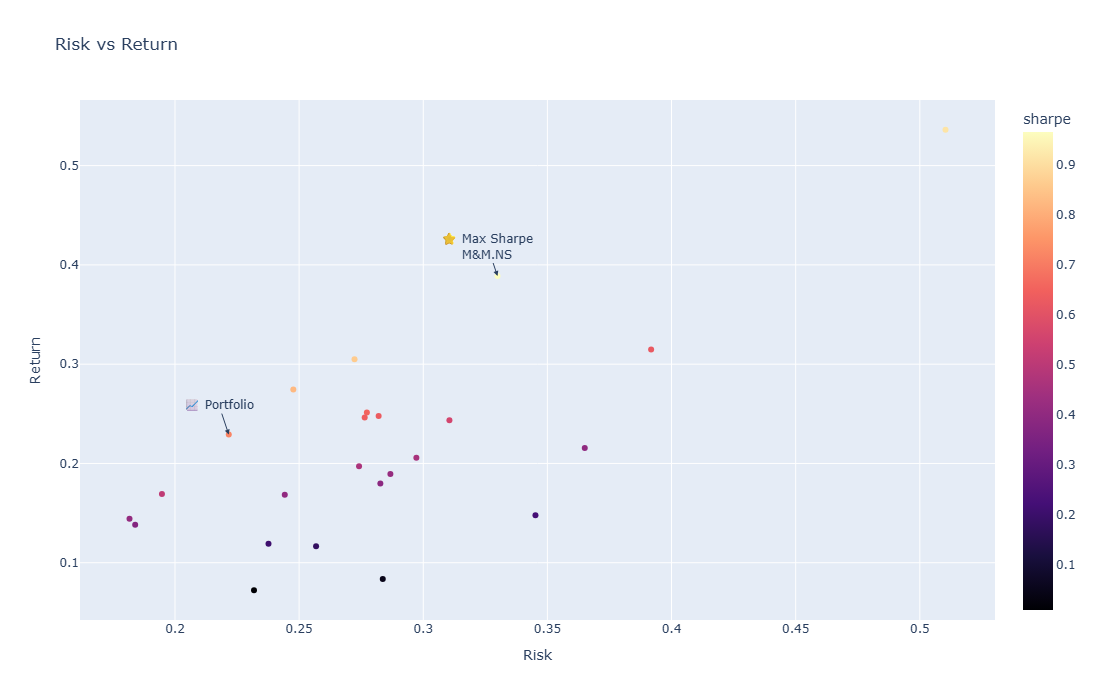

In [632]:
import plotly.express as px

max_sharpe_stock = result["sharpe"].idxmax()
portfolio_name = "Portfolio daily move"

fig = px.scatter(
    result,
    x="Risk",
    y="Return",
    color="sharpe",
    color_continuous_scale="Magma",
    hover_name=result.index,
    title="Risk vs Return"
)

# Max Sharpe label
fig.add_annotation(
    x=result.loc[max_sharpe_stock, "Risk"],
    y=result.loc[max_sharpe_stock, "Return"],
    text=f"⭐ Max Sharpe<br>{max_sharpe_stock}",
    showarrow=True,
    arrowhead=2
)

# Portfolio label
fig.add_annotation(
    x=result.loc[portfolio_name, "Risk"],
    y=result.loc[portfolio_name, "Return"],
    text=f"📈 Portfolio",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    width=1000,
    height=700
)

fig.show()

# OPtimizaing the Portfolio

In [639]:
matrix = np.random.random(20 * 10000).reshape(10000, 20)
weights = matrix / matrix.sum(axis = 1, keepdims= True)
weights

array([[0.07967058, 0.00330754, 0.07818927, ..., 0.01976463, 0.0316822 ,
        0.01340359],
       [0.03371477, 0.0333986 , 0.04680868, ..., 0.06723273, 0.07795563,
        0.079221  ],
       [0.05741641, 0.08557618, 0.00223773, ..., 0.04127262, 0.0307684 ,
        0.08788896],
       ...,
       [0.02362305, 0.02757244, 0.03680307, ..., 0.05413962, 0.02914943,
        0.02369258],
       [0.04438851, 0.07050756, 0.05598717, ..., 0.06618418, 0.03117983,
        0.06784029],
       [0.05287927, 0.00863578, 0.06573655, ..., 0.0738892 , 0.03446214,
        0.02583272]])

In [448]:
data_return = data.pct_change().dropna()

In [641]:
data_return

,ADANIENT.NS,ADANIPORTS.NS,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,MARUTI.NS,NTPC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TITAN.NS
Date,,,,,,,,,,,,,,,,,,,,
2020-01-02,0.016117,0.014564,0.011019,0.003486,0.004191,0.006374,0.000775,0.007173,-0.002918,0.007350,-0.001493,0.026986,0.006056,0.002482,-0.001234,0.017024,0.014501,0.001497,-0.004590,0.000736
2020-01-03,-0.013731,-0.001696,-0.018495,-0.012388,-0.000220,-0.014261,-0.005469,-0.003237,0.015380,-0.005628,-0.008645,-0.007619,-0.013152,-0.010314,-0.016886,0.001205,-0.016504,0.022187,0.019929,-0.013759
2020-01-06,-0.042007,-0.006013,-0.026516,-0.046918,-0.011975,-0.021641,-0.006226,-0.024404,-0.009585,-0.014256,-0.002746,-0.013707,-0.015486,-0.029203,-0.003771,-0.023192,-0.044052,-0.010459,-0.000091,0.016583
2020-01-07,0.022551,0.012099,0.003457,0.002740,-0.010119,0.015835,0.002741,-0.005326,-0.014820,0.001063,0.011074,0.002848,0.004099,0.004430,0.013877,0.015385,-0.001881,0.014661,0.002454,0.001165
2020-01-08,-0.012497,0.002209,-0.001722,0.010555,0.030892,-0.002618,0.004503,0.005833,-0.013326,-0.004886,-0.009576,-0.021923,-0.003797,-0.005429,-0.004977,-0.007510,0.004397,-0.014113,0.022395,-0.014354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,-0.006494,-0.010009,-0.006649,0.003572,-0.011501,0.009011,0.005722,-0.004019,-0.012606,0.011547,0.006047,-0.003340,0.002323,-0.003844,0.007951,-0.002983,-0.002463,-0.007854,-0.004481,-0.002034
2025-12-24,-0.011606,0.000469,0.001061,0.000297,0.000377,0.000602,-0.008860,-0.002348,-0.002937,-0.001841,0.000462,-0.001281,0.003200,0.007115,-0.002166,-0.007958,-0.003035,-0.010764,0.002719,-0.004203
2025-12-26,0.003239,-0.004818,0.001549,-0.011565,-0.008617,-0.005114,0.001402,-0.006913,-0.004389,-0.006026,0.000231,-0.001554,-0.003740,-0.006406,0.004805,0.000642,-0.002735,-0.010075,-0.011751,0.021155


In [643]:
mul_portfolio = data_return.dot(weights.T)

In [645]:
mul_portfolio

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,0.006590,0.005695,0.008573,0.006877,0.005463,0.007552,0.005557,0.005767,0.007024,0.005609,...,0.007156,0.006096,0.005871,0.009050,0.004975,0.005549,0.006538,0.006882,0.007896,0.004703
2020-01-03,-0.006204,-0.001679,-0.005561,-0.004868,-0.003490,-0.005226,-0.003345,-0.004158,-0.003888,-0.007610,...,-0.004901,-0.003230,-0.006550,-0.008337,-0.004143,-0.002933,-0.003329,-0.004941,-0.004216,-0.006144
2020-01-06,-0.018917,-0.014944,-0.015895,-0.018895,-0.014917,-0.017311,-0.017776,-0.015857,-0.015386,-0.017499,...,-0.016124,-0.014776,-0.017211,-0.020836,-0.019299,-0.014638,-0.015724,-0.019839,-0.016870,-0.017288
2020-01-07,0.003760,0.003050,0.006372,0.004178,0.007267,0.007287,0.004505,0.003981,0.004132,0.004456,...,0.006469,0.003941,0.005352,0.006643,0.003193,0.004967,0.002484,0.004233,0.004104,0.006043
2020-01-08,-0.002946,-0.000899,-0.001637,-0.002617,-0.002512,-0.003074,-0.000203,0.000408,-0.003793,-0.001391,...,-0.000808,-0.002683,-0.000391,-0.001945,0.002237,-0.002167,-0.002245,0.001218,-0.002741,-0.000696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,-0.001492,-0.003218,-0.002075,-0.001325,-0.002312,-0.001767,-0.002286,-0.002540,-0.001201,0.000132,...,-0.001489,-0.002128,-0.000050,-0.001435,-0.002114,-0.002691,-0.002791,-0.001652,-0.003238,0.000950
2025-12-24,-0.002009,-0.002468,-0.002682,-0.001452,-0.002900,-0.002260,-0.001883,-0.001023,-0.001864,-0.001210,...,-0.001459,-0.002215,-0.001400,-0.002561,-0.000842,-0.002879,-0.001489,-0.002860,-0.002342,-0.002742
2025-12-26,-0.002476,-0.002652,-0.001661,-0.002857,-0.001830,-0.003102,-0.003975,-0.003645,-0.002476,-0.002196,...,-0.003293,-0.002797,-0.002988,-0.001526,-0.004346,-0.001648,-0.002707,-0.003359,-0.002302,-0.003037


In [649]:
mul_port = ann_risk_return(mul_portfolio)

In [650]:
mul_port

,Return,Risk
0,0.226505,0.191714
1,0.211436,0.177813
2,0.246830,0.197408
3,0.204223,0.189381
4,0.236114,0.193448
...,...,...
9995,0.230430,0.184165
9996,0.204346,0.187064
9997,0.203560,0.187822
9998,0.237156,0.193589


In [653]:
mul_port["sharpe"] = (mul_port["Return"] -0.07).div(mul_port["Risk"])

In [655]:
result

,Return,Risk,sharpe,Total_Risk,Beta,Systamatic_Risk,Unsystimatic_risk,CAPM,Alpha
Portfolio daily move,0.229087,0.221663,0.717699,0.049134,1.017853,0.035063,0.014071,0.139576,0.089512
Nifty50,0.138355,0.183967,0.371562,0.033844,1.000000,0.033844,0.015290,0.138355,0.000000
NiftyNext50,0.144346,0.181679,0.409213,0.033007,0.983889,0.032762,0.016372,0.137254,0.007092
Sensex,0.169158,0.194745,0.509168,0.037926,0.856236,0.024812,0.024322,0.128528,0.040630
ADANIENT.NS,0.536128,0.510344,0.913361,0.260451,1.267043,0.054333,-0.005199,0.156609,0.379519
ADANIPORTS.NS,0.314812,0.391780,0.624873,0.153491,1.153155,0.045005,0.004130,0.148824,0.165988
AXISBANK.NS,0.147919,0.345190,0.225727,0.119156,1.328541,0.059735,-0.010601,0.160813,-0.012894
BAJFINANCE.NS,0.215640,0.365048,0.398962,0.133260,1.359802,0.062580,-0.013445,0.162950,0.052690
BHARTIARTL.NS,0.304883,0.272314,0.862548,0.074155,0.780723,0.020629,0.028506,0.123367,0.181517
HDFCBANK.NS,0.116662,0.256830,0.181685,0.065962,1.076758,0.039239,0.009895,0.143602,-0.026940


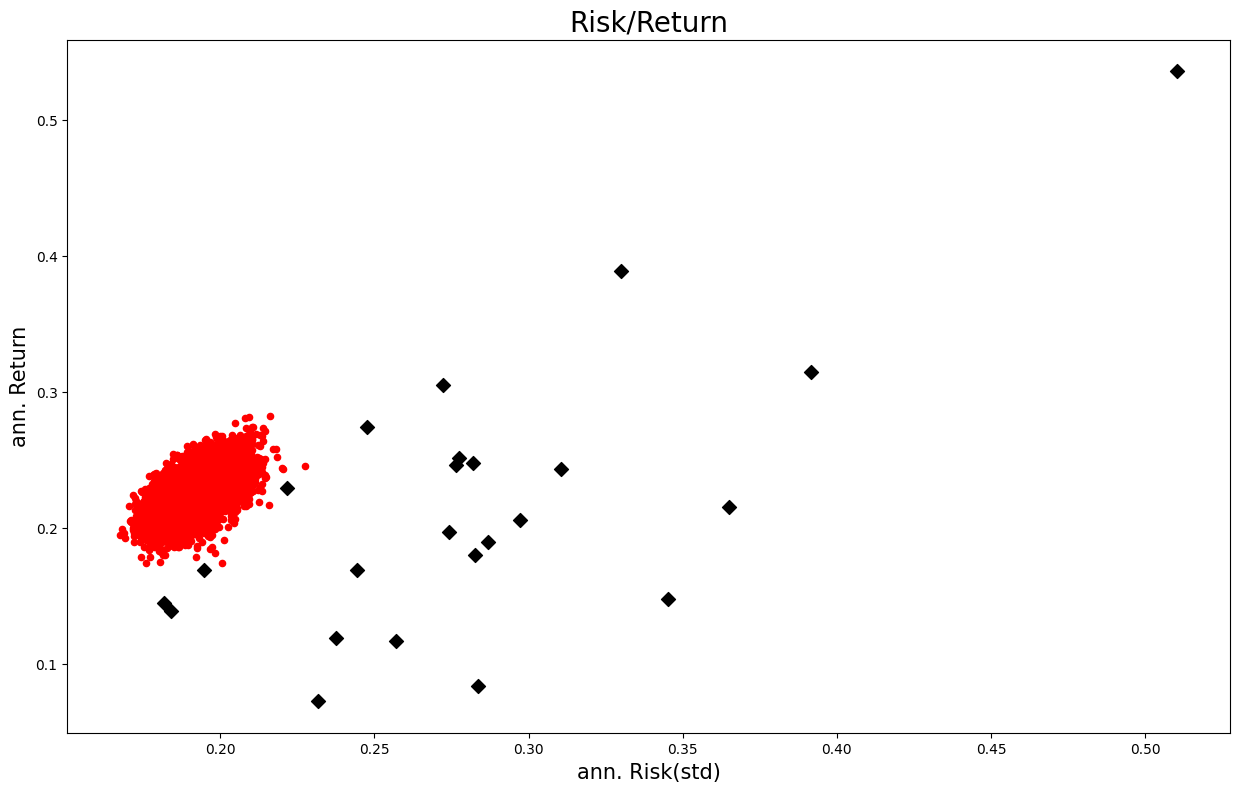

In [657]:
plt.figure(figsize = (15, 9))
plt.scatter(mul_port.loc[:, "Risk"], mul_port.loc[:, "Return"],s= 20, color = "red")
plt.scatter(result.loc[:, "Risk"], result.loc[:, "Return"], s= 50, color = "black", marker = "D")
plt.xlabel("ann. Risk(std)", fontsize = 15)
plt.ylabel("ann. Return", fontsize = 15)
plt.title("Risk/Return", fontsize = 20)
plt.show()

In [659]:
max_sharpe = mul_port["sharpe"].idxmax()
max_sharpe

2044

In [661]:
max_sharpe_wei = weights[max_sharpe]
max_sharpe_wei[0]

0.10591811137830379

In [663]:
Optimal_wei_stocks = {}
for i in range(len( max_sharpe_wei)):
    Optimal_wei_stocks[data_return.columns[i]] = max_sharpe_wei[i]

Optimal_wei_stocks

{'ADANIENT.NS': 0.10591811137830379,
 'ADANIPORTS.NS': 0.12148745040179333,
 'AXISBANK.NS': 0.05617170454647769,
 'BAJFINANCE.NS': 0.027490043285569213,
 'BHARTIARTL.NS': 0.12936109401429516,
 'HDFCBANK.NS': 0.02527503056740087,
 'HINDUNILVR.NS': 0.011319650457719559,
 'ICICIBANK.NS': 0.05171284878589414,
 'INFY.NS': 0.01813673112001164,
 'ITC.NS': 0.08211418706526805,
 'KOTAKBANK.NS': 0.006109303464754316,
 'LT.NS': 0.10563246772151089,
 'M&M.NS': 0.06928527674945112,
 'MARUTI.NS': 0.01894974450633605,
 'NTPC.NS': 0.05251622895908116,
 'RELIANCE.NS': 0.007834683795581438,
 'SBIN.NS': 0.005686317323605161,
 'SUNPHARMA.NS': 0.06212856743374134,
 'TCS.NS': 0.0034948185605381136,
 'TITAN.NS': 0.03937573986266699}

In [665]:
result

,Return,Risk,sharpe,Total_Risk,Beta,Systamatic_Risk,Unsystimatic_risk,CAPM,Alpha
Portfolio daily move,0.229087,0.221663,0.717699,0.049134,1.017853,0.035063,0.014071,0.139576,0.089512
Nifty50,0.138355,0.183967,0.371562,0.033844,1.000000,0.033844,0.015290,0.138355,0.000000
NiftyNext50,0.144346,0.181679,0.409213,0.033007,0.983889,0.032762,0.016372,0.137254,0.007092
Sensex,0.169158,0.194745,0.509168,0.037926,0.856236,0.024812,0.024322,0.128528,0.040630
ADANIENT.NS,0.536128,0.510344,0.913361,0.260451,1.267043,0.054333,-0.005199,0.156609,0.379519
ADANIPORTS.NS,0.314812,0.391780,0.624873,0.153491,1.153155,0.045005,0.004130,0.148824,0.165988
AXISBANK.NS,0.147919,0.345190,0.225727,0.119156,1.328541,0.059735,-0.010601,0.160813,-0.012894
BAJFINANCE.NS,0.215640,0.365048,0.398962,0.133260,1.359802,0.062580,-0.013445,0.162950,0.052690
BHARTIARTL.NS,0.304883,0.272314,0.862548,0.074155,0.780723,0.020629,0.028506,0.123367,0.181517
HDFCBANK.NS,0.116662,0.256830,0.181685,0.065962,1.076758,0.039239,0.009895,0.143602,-0.026940


In [671]:
sortino = {}

for col in combined.columns:

    down = combined[col][combined[col] < 0]

    down_std = down.std()

    annual_std = down_std * np.sqrt(252)

    sortino[col] = (
        result.loc[col, "Return"] - 0.07
    ) / annual_std

sortino

{'ADANIENT.NS': 1.1057467846561393,
 'ADANIPORTS.NS': 0.7660499530838858,
 'AXISBANK.NS': 0.2778611981326983,
 'BAJFINANCE.NS': 0.5006021787652302,
 'BHARTIARTL.NS': 1.2878987265271216,
 'HDFCBANK.NS': 0.23913276685861226,
 'HINDUNILVR.NS': 0.015250444342207086,
 'ICICIBANK.NS': 0.5711766123746863,
 'INFY.NS': 0.6581164877353485,
 'ITC.NS': 0.5444757262632893,
 'KOTAKBANK.NS': 0.0648318218452268,
 'LT.NS': 0.8526067405759162,
 'M&M.NS': 1.4446482525350601,
 'MARUTI.NS': 0.5676112107789685,
 'NTPC.NS': 0.9166365245926082,
 'RELIANCE.NS': 0.5512162280244803,
 'SBIN.NS': 0.72700176903482,
 'SUNPHARMA.NS': 1.2679181571632114,
 'TCS.NS': 0.2955222772814342,
 'TITAN.NS': 0.9407842980258546,
 'Portfolio daily move': 0.804491252580273,
 'Nifty50': 0.4321730839294739,
 'NiftyNext50': 0.47190726684126966,
 'Sensex': 0.5659862573357576}

In [673]:
sortino_df = pd.Series(sortino, name="Sortino").to_frame()

In [675]:
sortino_df

,Sortino
ADANIENT.NS,1.105747
ADANIPORTS.NS,0.766050
AXISBANK.NS,0.277861
BAJFINANCE.NS,0.500602
BHARTIARTL.NS,1.287899
HDFCBANK.NS,0.239133
HINDUNILVR.NS,0.015250
ICICIBANK.NS,0.571177
INFY.NS,0.658116
ITC.NS,0.544476


In [677]:
result["sortino_df"]  = sortino_df

In [679]:
result["Treynor Ratio"] = (result.loc[:,"Return"] -0.07)/result["Beta"]

In [681]:
result

,Return,Risk,sharpe,Total_Risk,Beta,Systamatic_Risk,Unsystimatic_risk,CAPM,Alpha,sortino_df,Treynor Ratio
Portfolio daily move,0.229087,0.221663,0.717699,0.049134,1.017853,0.035063,0.014071,0.139576,0.089512,0.804491,0.156297
Nifty50,0.138355,0.183967,0.371562,0.033844,1.000000,0.033844,0.015290,0.138355,0.000000,0.432173,0.068355
NiftyNext50,0.144346,0.181679,0.409213,0.033007,0.983889,0.032762,0.016372,0.137254,0.007092,0.471907,0.075563
Sensex,0.169158,0.194745,0.509168,0.037926,0.856236,0.024812,0.024322,0.128528,0.040630,0.565986,0.115807
ADANIENT.NS,0.536128,0.510344,0.913361,0.260451,1.267043,0.054333,-0.005199,0.156609,0.379519,1.105747,0.367887
ADANIPORTS.NS,0.314812,0.391780,0.624873,0.153491,1.153155,0.045005,0.004130,0.148824,0.165988,0.766050,0.212298
AXISBANK.NS,0.147919,0.345190,0.225727,0.119156,1.328541,0.059735,-0.010601,0.160813,-0.012894,0.277861,0.058650
BAJFINANCE.NS,0.215640,0.365048,0.398962,0.133260,1.359802,0.062580,-0.013445,0.162950,0.052690,0.500602,0.107104
BHARTIARTL.NS,0.304883,0.272314,0.862548,0.074155,0.780723,0.020629,0.028506,0.123367,0.181517,1.287899,0.300854
HDFCBANK.NS,0.116662,0.256830,0.181685,0.065962,1.076758,0.039239,0.009895,0.143602,-0.026940,0.239133,0.043336


In [683]:
new_index_option  =  pd.read_csv("newindex.csv",index_col= "Date" ,parse_dates = ["Date"] ).dropna()

In [685]:
new_index_option_ret = new_index_option.pct_change().dropna()

In [687]:
new_index_option_ret

,NASDAQ100,SP500,NIFTY50,SENSEX,NIKKEI225,DAX,FTSE100,CAC40,ASX200,HANGSENG
Date,,,,,,,,,,
2020-01-07,0.013466,0.004741,-0.000206,-0.000185,0.007606,-0.002803,0.003397,0.015982,-0.000234,0.004995
2020-01-08,-0.001289,-0.001266,0.003102,0.000132,0.007058,0.004902,-0.008267,-0.015735,0.007452,-0.002290
2020-01-09,0.008302,0.015547,0.001915,0.003063,0.013129,0.006655,0.016843,0.023060,0.008669,0.015846
2020-01-10,0.007972,0.003555,-0.000900,-0.001342,-0.000871,-0.002855,0.002703,0.004663,-0.002557,0.003348
2020-01-14,0.004791,0.008483,0.000626,0.004547,-0.001989,0.005451,0.008623,0.007321,0.007448,0.008607
...,...,...,...,...,...,...,...,...,...,...
2026-06-01,-0.000263,-0.006799,-0.004491,-0.006754,-0.004049,0.002625,0.008569,0.009119,0.005957,-0.007013
2026-06-02,-0.000573,0.005150,0.007672,0.003337,0.004845,0.001292,0.025204,-0.002989,0.004809,0.004317
2026-06-03,0.007026,-0.004068,-0.007147,-0.003972,-0.013064,-0.007372,-0.015558,0.024993,-0.002914,-0.003319


In [689]:
new_index_stats = ann_risk_return(new_index_option_ret)

In [691]:
new_index_stats["Sharpe"] = (new_index_stats["Return"]  -0.03)/new_index_stats["Risk"]

In [693]:
new_index_stats.loc["Portfolio"]  = 0

In [695]:
new_index_stats.loc["Portfolio","Return"] = result.loc["Portfolio daily move","Return"]
new_index_stats.loc["Portfolio","Risk"] = result.loc["Portfolio daily move","Risk"]
new_index_stats.loc["Portfolio","Sharpe"] = result.loc["Portfolio daily move","sharpe"]



In [697]:
new_index_stats

,Return,Risk,Sharpe
NASDAQ100,0.063020,0.180634,0.182801
SP500,0.132050,0.192622,0.529795
NIFTY50,0.082576,0.216953,0.242340
SENSEX,0.075704,0.181151,0.252300
NIKKEI225,0.144301,0.221729,0.515498
DAX,0.179354,0.220505,0.677326
FTSE100,0.011563,0.263232,-0.070042
CAC40,0.229224,0.246577,0.807958
ASX200,0.260193,0.270576,0.850753
HANGSENG,0.143936,0.190348,0.598569


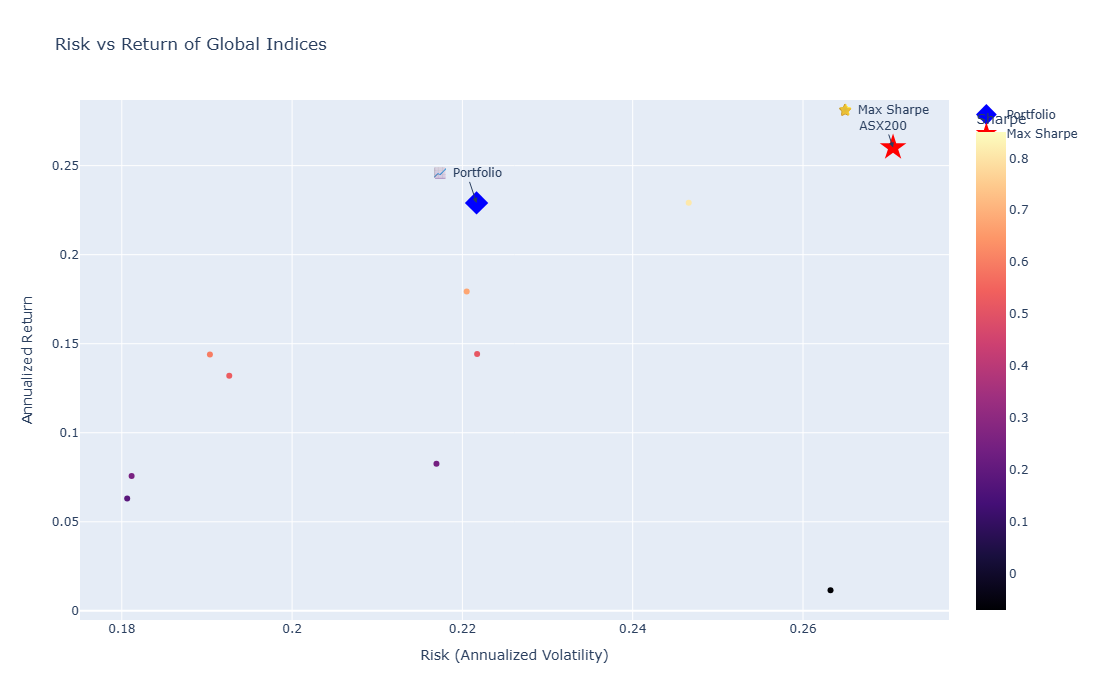

In [699]:
import plotly.express as px

# Find index with maximum Sharpe ratio
max_sharpe_index = new_index_stats["Sharpe"].idxmax()

# Create scatter plot
fig = px.scatter(
    new_index_stats,
    x="Risk",
    y="Return",
    color="Sharpe",
    color_continuous_scale="Magma",
    hover_name=new_index_stats.index,
    title="Risk vs Return of Global Indices"
)

# Highlight Portfolio
fig.add_annotation(
    x=new_index_stats.loc["Portfolio", "Risk"],
    y=new_index_stats.loc["Portfolio", "Return"],
    text="📈 Portfolio",
    showarrow=True,
    arrowhead=2
)

# Highlight Maximum Sharpe Index
fig.add_annotation(
    x=new_index_stats.loc[max_sharpe_index, "Risk"],
    y=new_index_stats.loc[max_sharpe_index, "Return"],
    text=f"⭐ Max Sharpe<br>{max_sharpe_index}",
    showarrow=True,
    arrowhead=2
)

# Make these two points larger
fig.add_scatter(
    x=[new_index_stats.loc["Portfolio", "Risk"]],
    y=[new_index_stats.loc["Portfolio", "Return"]],
    mode="markers",
    marker=dict(
        size=18,
        symbol="diamond",
        color="blue"
    ),
    name="Portfolio"
)

fig.add_scatter(
    x=[new_index_stats.loc[max_sharpe_index, "Risk"]],
    y=[new_index_stats.loc[max_sharpe_index, "Return"]],
    mode="markers",
    marker=dict(
        size=20,
        symbol="star",
        color="red"
    ),
    name="Max Sharpe"
)

fig.update_layout(
    width=1000,
    height=700,
    xaxis_title="Risk (Annualized Volatility)",
    yaxis_title="Annualized Return"
)

fig.show()

In [701]:
new_index_stats.sort_values("Sharpe",ascending = False)


,Return,Risk,Sharpe
ASX200,0.260193,0.270576,0.850753
CAC40,0.229224,0.246577,0.807958
Portfolio,0.229087,0.221663,0.717699
DAX,0.179354,0.220505,0.677326
HANGSENG,0.143936,0.190348,0.598569
SP500,0.132050,0.192622,0.529795
NIKKEI225,0.144301,0.221729,0.515498
SENSEX,0.075704,0.181151,0.252300
NIFTY50,0.082576,0.216953,0.242340
NASDAQ100,0.063020,0.180634,0.182801


In [703]:
currect_porfolio_statues  = new_index_stats.loc["Portfolio"].to_frame().T
currect_porfolio_statues

,Return,Risk,Sharpe
Portfolio,0.229087,0.221663,0.717699


In [705]:
data

,ADANIENT.NS,ADANIPORTS.NS,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,MARUTI.NS,NTPC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TITAN.NS
Date,,,,,,,,,,,,,,,,,,,,
2020-01-01,205.886520,362.584290,745.586853,413.532196,433.316467,605.529358,1749.931396,519.137939,633.151123,168.796616,333.417084,1180.674683,509.727966,6945.334961,94.731247,672.216187,303.138489,406.074005,1841.149536,1132.704834
2020-01-02,209.204865,367.864838,753.802612,414.973724,435.132690,609.389160,1751.286865,522.861633,631.303711,170.037216,332.919159,1212.536011,512.815125,6962.575684,94.614365,683.660217,307.534393,406.681763,1832.697754,1133.538574
2020-01-03,206.332260,367.240784,739.860901,409.833008,435.037109,600.698792,1741.708496,521.169006,641.013428,169.080215,330.041168,1203.297363,506.070770,6890.763184,93.016670,684.484009,302.458710,415.704620,1869.222046,1117.942017
2020-01-06,197.664932,365.032532,720.242737,390.604309,429.827362,587.698792,1730.864624,508.450500,634.869568,166.669830,329.134979,1186.803711,498.233917,6689.528809,92.665939,668.609314,289.134918,411.356781,1869.052246,1136.481201
2020-01-07,202.122406,369.449036,722.732300,391.674469,425.477966,597.004822,1735.608887,505.742401,625.460754,166.847046,332.779755,1190.183350,500.276245,6719.165527,93.951897,678.895691,288.591064,417.387543,1873.639038,1137.805298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,2248.800049,1493.599976,1225.000000,1011.400024,2122.899902,996.599976,2302.600098,1363.000000,1668.300049,388.406677,432.540009,4019.539795,3625.100098,16585.000000,320.827820,1563.471069,954.691650,1744.567627,3207.412598,3925.800049
2025-12-24,2222.699951,1494.300049,1226.300049,1011.700012,2123.699951,997.200012,2282.199951,1359.800049,1663.400024,387.691559,432.739990,4014.390137,3636.699951,16703.000000,320.133057,1551.028687,951.793884,1725.789673,3216.133789,3909.300049
2025-12-26,2229.899902,1487.099976,1228.199951,1000.000000,2105.399902,992.099976,2285.399902,1350.400024,1656.099976,385.355469,432.839996,4008.150879,3623.100098,16596.000000,321.671448,1552.024048,949.190735,1708.402588,3178.342529,3992.000000


In [707]:
new_index_option_ret[["ASX200","CAC40"]]

,ASX200,CAC40
Date,,
2020-01-07,-0.000234,0.015982
2020-01-08,0.007452,-0.015735
2020-01-09,0.008669,0.023060
2020-01-10,-0.002557,0.004663
2020-01-14,0.007448,0.007321
...,...,...
2026-06-01,0.005957,0.009119
2026-06-02,0.004809,-0.002989
2026-06-03,-0.002914,0.024993


In [709]:
combined_new = pd.concat([data_ret, new_index_option_ret[["ASX200","CAC40"]]], axis=1).dropna()


In [711]:
combined_new

,ADANIENT.NS,ADANIPORTS.NS,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,...,M&M.NS,MARUTI.NS,NTPC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TITAN.NS,ASX200,CAC40
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-07,0.022551,0.012099,0.003457,0.002740,-0.010119,0.015835,0.002741,-0.005326,-0.014820,0.001063,...,0.004099,0.004430,0.013877,0.015385,-0.001881,0.014661,0.002454,0.001165,-0.000234,0.015982
2020-01-08,-0.012497,0.002209,-0.001722,0.010555,0.030892,-0.002618,0.004503,0.005833,-0.013326,-0.004886,...,-0.003797,-0.005429,-0.004977,-0.007510,0.004397,-0.014113,0.022395,-0.014354,0.007452,-0.015735
2020-01-09,0.032258,0.015947,0.025328,0.018334,0.002724,0.011215,0.002954,0.038692,0.013019,0.006832,...,0.031640,0.027391,-0.005002,0.023031,0.032520,-0.000568,-0.018136,0.017624,0.008669,0.023060
2020-01-10,0.005288,0.000638,-0.003769,0.005007,-0.006738,0.008888,0.009793,-0.011074,0.014570,0.009330,...,0.009885,0.014195,0.007960,-0.000226,0.006208,0.008526,-0.000361,-0.008079,-0.002557,0.004663
2020-01-14,0.003511,-0.002946,0.014239,0.006844,0.000960,0.002722,0.006993,-0.001857,0.002715,0.016719,...,0.013605,0.004638,0.014374,-0.009263,-0.008314,0.003149,0.007556,0.007032,0.007448,0.007321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-19,0.004351,0.000468,0.000650,0.007998,0.002725,0.005920,0.006400,-0.001990,0.007315,0.001623,...,0.004740,0.005205,0.004396,0.013403,0.002813,-0.000573,0.000366,0.002756,0.013062,0.010320
2025-12-22,0.010942,0.008220,0.002113,-0.000496,0.023788,0.002232,0.004167,0.010634,0.031061,0.004114,...,0.003635,0.014317,0.002501,0.006581,-0.006121,0.014270,0.013071,0.000941,0.004558,0.018082
2025-12-23,-0.006494,-0.010009,-0.006649,0.003572,-0.011501,0.009011,0.005722,-0.004019,-0.012606,0.011547,...,0.002323,-0.003844,0.007951,-0.002983,-0.002463,-0.007854,-0.004481,-0.002034,0.004954,0.000208


In [713]:
matrix_new = np.random.random(
    len(combined_new.columns) * 100000
).reshape(
    100000,
    len(combined_new.columns)
)

weights_new = matrix_new / matrix_new.sum(axis=1, keepdims=True)

In [715]:
combined_new_port  = combined_new.dot(weights_new.T)

In [716]:
combined_new_port

,0,1,2,3,4,5,6,7,8,9,...,99990,99991,99992,99993,99994,99995,99996,99997,99998,99999
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-07,0.005886,0.005386,0.003760,0.005869,0.005199,0.005527,0.005453,0.004642,0.004459,0.004293,...,0.006762,0.005490,0.003130,0.004160,0.004153,0.004682,0.004857,0.004167,0.004377,0.004920
2020-01-08,-0.003149,-0.001968,-0.000767,-0.003047,-0.003596,-0.002565,-0.001793,-0.004775,0.000688,-0.001350,...,-0.002939,0.000183,-0.002596,-0.001263,-0.003040,-0.003645,-0.002093,-0.002009,-0.000836,-0.000395
2020-01-09,0.013322,0.014874,0.012488,0.016248,0.013763,0.015248,0.014680,0.016613,0.013491,0.015381,...,0.015088,0.015603,0.015417,0.015998,0.013613,0.016194,0.014143,0.014962,0.014864,0.013365
2020-01-10,0.003876,0.003528,0.004118,0.002848,0.003701,0.004426,0.004689,0.003622,0.002036,0.003334,...,0.004576,0.002966,0.004344,0.002041,0.005204,0.005210,0.003958,0.004339,0.004593,0.003262
2020-01-14,0.004913,0.004468,0.003986,0.002031,0.004482,0.003274,0.002845,0.003003,0.003989,0.004919,...,0.003405,0.003378,0.003011,0.003706,0.004147,0.003021,0.003606,0.004001,0.004524,0.004407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-19,0.004207,0.004046,0.004167,0.004610,0.003650,0.004241,0.005032,0.004288,0.003416,0.004224,...,0.004786,0.004005,0.003584,0.004542,0.004175,0.004331,0.005007,0.003852,0.004180,0.004229
2025-12-22,0.007938,0.005880,0.008283,0.007551,0.008034,0.005795,0.009298,0.007217,0.010042,0.007109,...,0.006980,0.005957,0.008824,0.006603,0.008251,0.007818,0.008973,0.007052,0.006384,0.007223
2025-12-23,-0.001685,-0.000603,-0.001479,-0.002097,-0.000958,-0.000298,-0.001557,-0.002365,-0.003165,-0.000812,...,-0.000506,-0.001292,-0.002449,-0.001360,-0.001186,-0.002195,-0.002393,-0.001425,-0.000811,-0.000763


In [719]:
new_final_port = ann_risk_return(combined_new_port)

In [720]:
new_final_port["Sharpe"] = (new_final_port["Return"]  -0.07)/new_final_port["Risk"]


new_final_port

,Return,Risk,Sharpe
0,0.215489,0.174455,0.833961
1,0.222918,0.186243,0.821069
2,0.214282,0.181252,0.796029
3,0.227340,0.197093,0.798303
4,0.190927,0.176806,0.683955
...,...,...,...
99995,0.231376,0.186493,0.865321
99996,0.212464,0.178947,0.796121
99997,0.208290,0.189033,0.731568
99998,0.207712,0.187229,0.735524


In [723]:
max_sharpe = new_final_port["Sharpe"].idxmax()
max_sharpe
max_sharpe_wei_op = weights_new[max_sharpe]

max_sharpe_wei_op


array([0.08598917, 0.02547369, 0.00339025, 0.02356014, 0.10216104,
       0.00739001, 0.00987889, 0.03989955, 0.04020979, 0.00059046,
       0.00966427, 0.07281958, 0.02546189, 0.04726873, 0.08621271,
       0.04473169, 0.04420346, 0.10869215, 0.00591287, 0.08804857,
       0.01717183, 0.11126924])

In [725]:
Optimal_wei_stocks_new= {}
for i in range(len( max_sharpe_wei_op)):
    Optimal_wei_stocks_new[combined_new.columns[i]] = max_sharpe_wei_op[i]

Optimal_wei_stocks_new

{'ADANIENT.NS': 0.0859891699094369,
 'ADANIPORTS.NS': 0.025473693596674774,
 'AXISBANK.NS': 0.003390254815744536,
 'BAJFINANCE.NS': 0.02356013720950466,
 'BHARTIARTL.NS': 0.10216103969029375,
 'HDFCBANK.NS': 0.0073900146227388434,
 'HINDUNILVR.NS': 0.00987888990538886,
 'ICICIBANK.NS': 0.039899554666500414,
 'INFY.NS': 0.040209793471864375,
 'ITC.NS': 0.0005904649258841003,
 'KOTAKBANK.NS': 0.00966426921334121,
 'LT.NS': 0.07281957623496217,
 'M&M.NS': 0.025461891168283273,
 'MARUTI.NS': 0.04726873065509829,
 'NTPC.NS': 0.08621270923469572,
 'RELIANCE.NS': 0.04473168566587217,
 'SBIN.NS': 0.0442034631462636,
 'SUNPHARMA.NS': 0.10869215334367924,
 'TCS.NS': 0.0059128661574066824,
 'TITAN.NS': 0.0880485701095007,
 'ASX200': 0.01717183073648779,
 'CAC40': 0.11126924152037801}

In [727]:
optimal_new_port = new_final_port.iloc[max_sharpe].to_frame()

In [729]:
optimal_new_port.columns =["Optimal portfolio"]

In [731]:
optimal_new_port

,Optimal portfolio
Return,0.267367
Risk,0.183389
Sharpe,1.076220


In [733]:
currect_porfolio_statues.T

,Portfolio
Return,0.229087
Risk,0.221663
Sharpe,0.717699
